# 🩺 Silent Risk — Predicting Chronic Disease Before It Strikes

---

> **Context:** A national health insurer wants to identify high-risk members before they develop costly chronic conditions. This project leverages the CDC BRFSS 2024 survey (~400k respondents) to predict diabetes risk and multi-morbidity, and to map prevention priorities geographically.

---

## Section 0 — Introduction & Business Context

---

### Section 0.1 — Project Pitch

#### The Problem

Health insurers operate in a fundamentally reactive model: claims arrive, costs are absorbed, and interventions come too late. Chronic diseases — diabetes, heart disease, depression, COPD — develop silently over years before they surface as expensive medical events.

#### The Opportunity

The CDC BRFSS survey captures exactly the behavioral and demographic signals that precede chronic disease: smoking habits, physical inactivity, income stress, lack of healthcare access. These signals are observable **before** diagnosis.

#### The Solution

A predictive risk engine that:
- Scores individuals by probability of diabetes and multi-morbidity
- Segments the population into actionable risk tiers
- Maps prevention priorities geographically by state
- Identifies the highest-risk undetected profiles for proactive outreach

#### Business Value

| Stakeholder | Value |
|---|---|
| Actuaries | Earlier risk pricing and reserving |
| Prevention teams | Targeted outreach to high-risk members |
| Medical direction | Evidence-based program design |
| Regional agencies | Geographic prioritization of resources |

### Section 0.2 — Dataset Architecture

The BRFSS is a state-based surveillance system collecting data on health risk behaviors, chronic conditions, and use of preventive services among US adults. Data is collected via telephone interviews across all 50 states and territories.

The 2024 dataset is organized into thematic sections:

| Section | Content | Variables |
|---|---|---|
| Record Identification | State, date, sampling unit | 9 |
| Health Status | General health, healthy days | 4 |
| Healthcare Access | Insurance, provider, cost barriers | 4 |
| Chronic Conditions | Diabetes, heart disease, cancer, COPD, depression, kidney disease, arthritis | 13 |
| Demographics | Age, sex, income, education, employment, marital status | 13 |
| Behavioral Risk | Tobacco, alcohol, physical activity | 9 |
| Disability | Hearing, vision, mobility, cognition | 6 |
| Cancer Screening | Breast, cervical, colorectal, lung | 28 |
| Immunization | Flu shot, pneumonia vaccine | 4 |
| HIV/AIDS | Testing, risk factors | 3 |

**Key design note.** BRFSS uses special codes for missing data that must be handled carefully:

| Code | Meaning |
|---|---|
| `7` / `77` / `777` | Don't know / Not sure |
| `9` / `99` / `999` | Refused |
| `BLANK` | Not asked or missing |

### Section 0.3 — Setup: Imports & Data Loading

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay,
                             PrecisionRecallDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import lightgbm as lgb
import shap
import sqlite3

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

# Load dataset
DATA_PATH = '/Users/arvind.b/brfss-data/LLCP2024.csv'
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]:,}")

/Users/arvind.b/anaconda3/envs/silent-risk/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset loaded successfully
   Rows    : 457,670
   Columns : 301


## Section 1 — Business Framing

### Section 1.1 — Business Context

**Company:** MutuelSanté (fictional national health insurer)
**Portfolio:** 2.3 million insured members across all 50 US states
**Problem:** Claims costs are rising driven by preventable chronic conditions — diabetes, heart disease, depression, COPD. The insurer currently has no early warning system to identify high-risk members before diagnosis.

**Objective:** Build a predictive risk engine using behavioral and demographic data to:
- Identify members at high risk of diabetes and multi-morbidity **before** clinical diagnosis
- Map geographic and socioeconomic prevention priorities
- Design targeted, cost-effective intervention programs

**Why BRFSS 2024?**
The CDC BRFSS survey captures exactly the upstream signals that precede chronic disease: lifestyle behaviors, healthcare access barriers, socioeconomic stress. These signals are observable today — before the claim arrives.

**Expected business impact:**
| Lever | Estimated Impact |
|---|---|
| Early identification of diabetic risk profiles | Reduce late-stage claims by targeting prevention early |
| Geographic prioritization | Concentrate prevention budgets where risk is highest |
| Behavioral intervention programs | Address modifiable risk factors before irreversible damage |

### Section 1.2 — The Two Types of Errors & Their Cost

In a risk prediction model, two types of errors have very different business consequences for a health insurer.

| Error Type | Definition | Business Consequence | Estimated Cost |
|---|---|---|---|
| **False Negative** | High-risk member predicted as low-risk | No intervention triggered — member develops condition undetected | High — late-stage treatment costs, hospitalizations, chronic disease management |
| **False Positive** | Low-risk member predicted as high-risk | Unnecessary prevention outreach triggered | Low — cost of a prevention program or medical checkup |

**Key insight:** For MutuelSanté, a missed high-risk member (false negative) is far more costly than an unnecessary intervention (false positive). The average cost of managing a diabetic member is 2-3x higher than a non-diabetic member annually.

**Modeling consequence:** We will optimize for **Recall** (minimizing false negatives) rather than raw Accuracy. The decision threshold will be set conservatively to capture as many true high-risk profiles as possible, accepting a higher false positive rate.

### Section 1.3 — Stakeholders

| Stakeholder | Role | How They Use This Model |
|---|---|---|
| **Actuaries** | Risk pricing and reserving | Adjust premiums and reserves based on predicted risk scores |
| **Prevention Teams** | Member outreach and programs | Target high-risk members for prevention programs and checkups |
| **Medical Direction** | Clinical strategy | Design evidence-based intervention protocols by risk tier |
| **Regional Agencies** | Geographic resource allocation | Prioritize prevention budgets by state based on risk maps |
| **Data & IT Teams** | Model deployment and monitoring | Integrate risk scores into CRM and member management systems |

**Primary end user of this analysis:** Prevention Teams and Regional Agencies — they need actionable segments and geographic maps, not just model metrics.

### Section 1.4 — The Three Business Questions

These three questions structure the entire analysis and will be answered explicitly in Section 6.

---

**Q1. Which profiles present the highest risk of diabetes or multi-morbidity, and how can they be identified before diagnosis?**

> Answered by: Sections 2, 4, 5
> Deliverable: Risk scoring model + high-risk profile description

---

**Q2. In which states and socioeconomic segments is under-utilization of healthcare most critical?**

> Answered by: Sections 2.6, 2.7, 7
> Deliverable: Geographic risk map + socioeconomic segmentation

---

**Q3. Which modifiable behaviors are the most actionable levers to reduce risk in the short term?**

> Answered by: Sections 2.5, 5.1, 5.2
> Deliverable: Ranked behavioral levers with SHAP-based evidence

## Section 2 — Exploratory Data Analysis

### Section 2.1 — General Dataset Audit

Before any analysis, we need to understand the structure of the dataset: variable types, missing values, and BRFSS-specific coding conventions.

**BRFSS special codes to handle:**
- `7` / `77` / `777` / `7777` / `77777` — Don't know / Not sure
- `9` / `99` / `999` / `9999` / `99999` — Refused
- `BLANK` / `NaN` — Not asked or missing

In [7]:
# --- 2.1 General Dataset Audit ---

# Shape
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

# Data types
print("--- Data Types ---")
print(df.dtypes.value_counts())
print()

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print("--- Top 20 Variables by Missing Rate ---")
print(missing_df[missing_df['missing_count'] > 0].head(20))
print()

# Overall missing rate
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"Overall missing rate: {total_missing / total_cells * 100:.2f}%")

Dataset shape: 457,670 rows x 301 columns

--- Data Types ---
float64    298
int64        3
Name: count, dtype: int64

--- Top 20 Variables by Missing Rate ---
          missing_count  missing_pct
RCSGEND1         457670     100.0000
RCSXBRTH         457670     100.0000
COLGHOUS         457656     100.0000
CSRVCTL2         457088      99.8700
ICFQSTVR         456931      99.8400
CCLGHOUS         456244      99.6900
HPVDSHT          455650      99.5600
CSRVINST         455045      99.4300
NOBCUSE8         454899      99.3900
LASTSIG4         454443      99.2900
CSRVDEIN         454126      99.2300
CSRVCLIN         454128      99.2300
CSRVDOC1         454108      99.2200
CSRVSUM          454114      99.2200
CSRVINSR         454123      99.2200
CSRVRTRN         454118      99.2200
HPVADSH1         454043      99.2100
CASTHNO2         452865      98.9500
NUMPHON4         452048      98.7700
CSRVPAIN         451664      98.6900

Overall missing rate: 48.36%


<Figure size 1200x500 with 0 Axes>

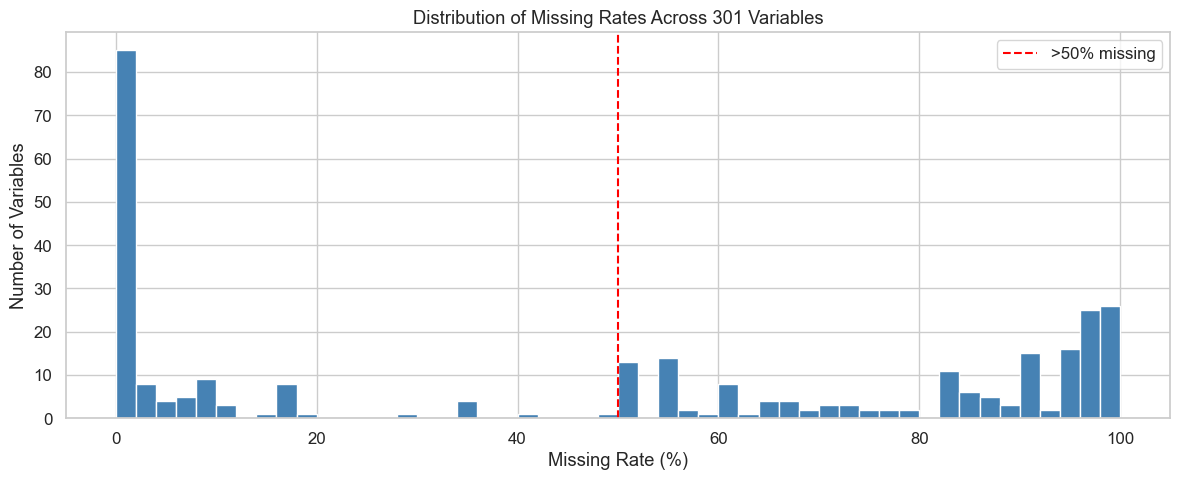

Variables with 0% missing    : 50
Variables with >50% missing  : 170
Variables with <50% missing  : 131


In [11]:
# Distribution of missing rates across all variables
os.makedirs('reports/figures', exist_ok=True)
os.makedirs('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures', exist_ok=True)
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/missing_rate_distribution.png', dpi=150)

fig, ax = plt.subplots(figsize=(12, 5))

missing_pct_all = (df.isnull().sum() / len(df) * 100)

ax.hist(missing_pct_all, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Missing Rate (%)')
ax.set_ylabel('Number of Variables')
ax.set_title('Distribution of Missing Rates Across 301 Variables')

# Annotations
n_zero = (missing_pct_all == 0).sum()
n_high = (missing_pct_all > 50).sum()
n_total = len(missing_pct_all)

ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='>50% missing')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/missing_rate_distribution.png', 
            dpi=150, facecolor='white')
plt.show()

print(f"Variables with 0% missing    : {n_zero}")
print(f"Variables with >50% missing  : {n_high}")
print(f"Variables with <50% missing  : {n_total - n_high}")

#### Audit Findings

- **301 variables** total, all numeric (float64/int64)
- **50 variables** with 0% missing — core variables asked to all respondents
- **170 variables** with >50% missing — module-specific variables asked to subgroups only
- **Overall missing rate: 48.36%** — expected for a survey dataset of this structure

**Design implication:** Feature engineering will focus on the ~130 variables with <50% missing. Variables at 100% missing will be dropped immediately. BRFSS special codes (7/9 series) are not true missing values — they will be recoded explicitly in Section 3.

### Section 2.2 — Target Variable Analysis: DIABETE4 + CDC Benchmark

In [12]:
# --- 2.2 Target Variable Analysis ---

# DIABETE4 value counts
print("--- DIABETE4 Raw Value Counts ---")
print(df['DIABETE4'].value_counts(dropna=False).sort_index())
print()

# BRFSS coding for DIABETE4:
# 1 = Yes
# 2 = Yes, but only during pregnancy
# 3 = No
# 4 = No, pre-diabetes or borderline diabetes
# 7 = Don't know / Not sure
# 9 = Refused
# NaN = Missing

--- DIABETE4 Raw Value Counts ---
DIABETE4
1.0000     65809
2.0000      3395
3.0000    376125
4.0000     11307
7.0000       798
9.0000       232
NaN            4
Name: count, dtype: int64



In [13]:
# --- DIABETE4 Clean Distribution + CDC Benchmark ---

# Recode for analysis
diabete_map = {
    1.0: 'Diabetic',
    2.0: 'Gestational only',
    3.0: 'No',
    4.0: 'Pre-diabetic',
    7.0: 'Don\'t know',
    9.0: 'Refused'
}

df['DIABETE4_label'] = df['DIABETE4'].map(diabete_map)

# Count and percentage
counts = df['DIABETE4_label'].value_counts(dropna=True)
pcts = (counts / counts.sum() * 100).round(2)

dist_df = pd.DataFrame({'Count': counts, 'Percentage': pcts})
print("--- DIABETE4 Distribution ---")
print(dist_df)
print()

# For modeling: binary target
# Positive class = 1 (Diabetic) — exclude gestational, don't know, refused, NaN
df_model = df[df['DIABETE4'].isin([1.0, 3.0, 4.0])].copy()
df_model['TARGET_DIABETES'] = (df_model['DIABETE4'] == 1.0).astype(int)

total = len(df_model)
positive = df_model['TARGET_DIABETES'].sum()
print(f"--- Binary Target for Modeling ---")
print(f"Total usable rows     : {total:,}")
print(f"Diabetic (1)          : {positive:,} ({positive/total*100:.2f}%)")
print(f"Non-diabetic (0)      : {total-positive:,} ({(total-positive)/total*100:.2f}%)")
print()

# C

/var/folders/39/9v2r64292m98c6c1_qf1hf_r0000gn/T/ipykernel_14565/1613455323.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DIABETE4_label'] = df['DIABETE4'].map(diabete_map)


--- DIABETE4 Distribution ---
                   Count  Percentage
DIABETE4_label                      
No                376125     82.1800
Diabetic           65809     14.3800
Pre-diabetic       11307      2.4700
Gestational only    3395      0.7400
Don't know           798      0.1700
Refused              232      0.0500

--- Binary Target for Modeling ---
Total usable rows     : 453,241
Diabetic (1)          : 65,809 (14.52%)
Non-diabetic (0)      : 387,432 (85.48%)



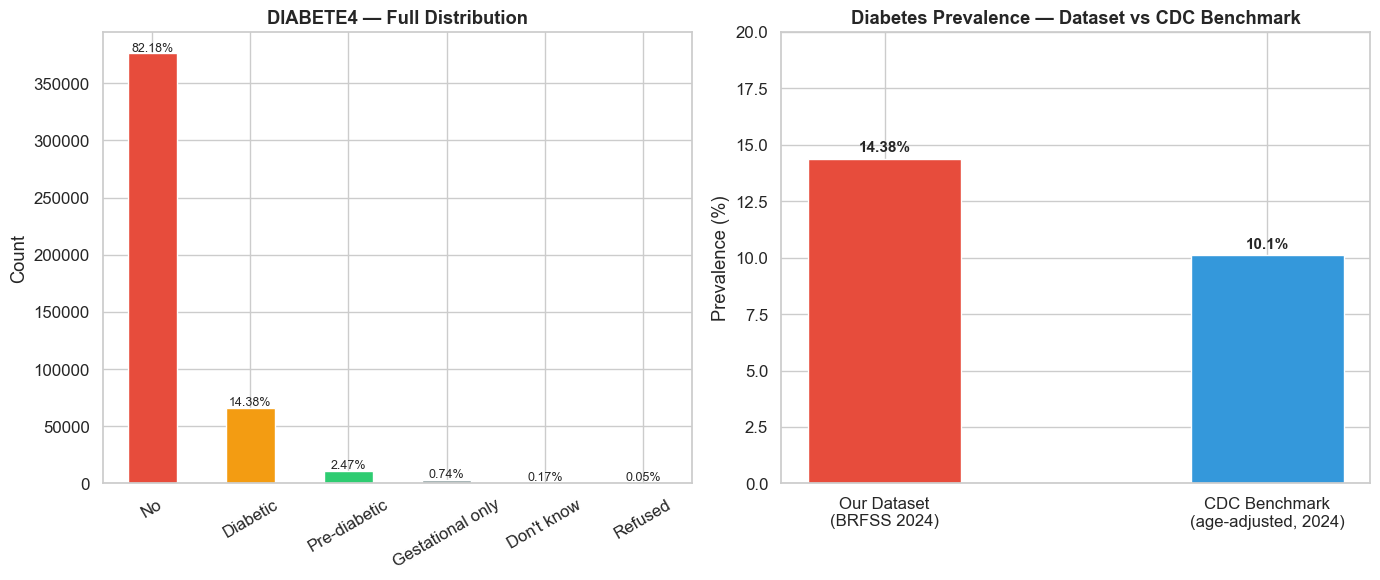

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Full distribution
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6', '#bdc3c7', '#ecf0f1']
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('DIABETE4 — Full Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (count, pct) in enumerate(zip(counts, pcts)):
    axes[0].text(i, count + 2000, f'{pct}%', ha='center', fontsize=9)

# Plot 2 — Binary target vs CDC benchmark
categories = ['Our Dataset\n(BRFSS 2024)', 'CDC Benchmark\n(age-adjusted, 2024)']
values = [14.38, 10.1]
bar_colors = ['#e74c3c', '#3498db']
bars = axes[1].bar(categories, values, color=bar_colors, edgecolor='white', width=0.4)
axes[1].set_title('Diabetes Prevalence — Dataset vs CDC Benchmark', fontweight='bold')
axes[1].set_ylabel('Prevalence (%)')
axes[1].set_ylim(0, 20)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val}%',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/target_distribution.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Target Variable

- **14.38% diabetic rate** in the full dataset vs **10.1% CDC benchmark** (age-adjusted diagnosed diabetes, NCHS Data Brief No.516, Nov 2024)
- The +4.3pp gap is explained by BRFSS sampling bias toward older adults via telephone interviews — no age-adjustment applied here
- **Binary modeling target: 14.52% positive class** — calculated on 453,241 rows after excluding gestational, don't know, refused, and missing values
- **Class imbalance: 85.5% / 14.5%** — moderate imbalance, manageable with class weighting in LightGBM
- **2.47% pre-diabetic** — not yet diabetic but on a trajectory. Captured in the multi-morbidity target in Section 3
- **Gestational, don't know, refused excluded** from modeling target — 3,627 rows removed

**Modeling note:** Binary target `TARGET_DIABETES` defined on 453,241 rows. Positive class = diagnosed diabetes (DIABETE4 = 1).